# Proxy Statistics

In [1]:
import os
import re
import json
import math
from common import *
from pathlib import Path
from collections import defaultdict
from data import RawDataFile
from experiment import Treatment, NetworkSetting
from treatments.picoquic import treatment_map as http_treatment_map
from treatments.media import treatment_map as media_treatment_map

## Collect data

```
# Build the proxy with debug logging of cache statistics
cd $SIDEKICK_HOME/deps/
./build_deps.sh 8
```

In [2]:
# Make the data directory
http_data_home = f'{DATA_HOME}/proxy_statistics/http'
media_data_home = f'{DATA_HOME}/proxy_statistics/media'
os.system(f'mkdir -p {http_data_home}')
os.system(f'mkdir -p {media_data_home}')

0

In [43]:
# HTTP benchmark
loss4 = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
loss16 = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=16, loss2=0)
def gen_http_cmd(label, time_s, network_setting=loss4):
    treatment = http_treatment_map[label]
    data_size = 125000 * 20 * time_s # 125000 * bottleneck_bw * time_s
    return RawDataFile(treatment, network_setting, '').cmd(data_size=data_size, num_trials=1, debug=True, logdir=f'{http_data_home}/{network_setting.label()}/{label}')

http_labels = [
    'picoquic_sidekick_30ms_freq10',
    'picoquic_sidekick_30ms_hint_freq10',
    'picoquic_iblt_30ms_freq10',
    'picoquic_iblt_30ms_hint_freq10',
    'picoquic_iblt_30ms_hint_freq10_cache48000',
    'picoquic_iblt_30ms_hint_freq10_cache16000',
    'picoquic_iblt_30ms_hint_freq10_reset',
    'picoquic_iblt_30ms_hint_freq10_cache48000_reset',
    'picoquic_iblt_30ms_hint_freq10_cache16000_reset',
]
for label in http_labels:
    print(gen_http_cmd(label, 10))

print()
print(gen_http_cmd('picoquic_sidekick_30ms_hint_freq10', 10, network_setting=loss16))
print(gen_http_cmd('picoquic_iblt_30ms_hint_freq10', 10, network_setting=loss16))
print(gen_http_cmd('picoquic_sidekick_30ms_freq10', 10, network_setting=loss16))
print(gen_http_cmd('picoquic_iblt_30ms_freq10', 10, network_setting=loss16))

sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http/network_20_20_1_100_None_None_4_0/picoquic_sidekick_30ms_freq10 --label picoquic_sidekick_30ms_freq10 --proxy sidekick --freq-ms 10 --freq-pkts 25 --threshold 25 --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http/network_20_20_1_100_None_None_4_0/picoquic_sidekick_30ms_hint_freq10 --label picoquic_sidekick_30ms_hint_freq10 --proxy sidekick --freq-ms 10 --freq-pkts 25 --threshold 25 --quack-hint --network-statistics picoquic --client-quacker --ack-delay 30 -n 25000000
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 -t 1 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/http/network

In [4]:
# Media benchmark
def gen_media_cmd(label, time_s):
    treatment = media_treatment_map[label]
    network_setting = NetworkSetting(bw1=20, bw2=20, delay1=1, delay2=100, loss1=4, loss2=0)
    return RawDataFile(treatment, network_setting, '').cmd(duration=time_s, debug=True, logdir=f'{media_data_home}/{label}')

media_labels = [
    'psum_delay0',
    'psum_delay45',
    'psum_delay90',
    'psum_delay45_hint',
    'psum_delay45_nack',
    'psum_delay45_hint_nack',
    'iblt_delay0',
    'iblt_delay45',
    'iblt_delay90',
    'iblt_delay45_hint',
    'iblt_delay45_nack',
    'iblt_delay45_hint_nack',
    'iblt_delay45_hint_nack_cache2000',
    'iblt_delay45_hint_nack_cache10000',
    'psum_delay45_hint_nack_cache10000',
]
for label in media_labels:
    print(gen_media_cmd(label, 10))

sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media/psum_delay0 --label psum_delay0 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 0 --duration 10
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media/psum_delay45 --label psum_delay45 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 45 --duration 10
sudo -E python3 emulation/main.py --bw1 20 --bw2 20 --delay2 100 --loss1 4 --loss2 0 --debug --logdir /home/ubuntu/sidekick-downloads/data/proxy_statistics/media/psum_delay90 --label psum_delay90 --proxy sidekick --freq-ms 0 --threshold 8 --freq-pkts 2 --network-statistics media --client-quacker --ack-delay 90 --duration 10
sudo -E python3 emulation

## Decode statistics

In [5]:
def parse_decode_statistics(data_home, label, normalize=True):
    # Read the raw data file
    filename = f'{data_home}/{label}/router.log'
    if not Path(filename).is_file():
        print('MISSING:', filename)
        return
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the number of missing elements in each decoded quACK
    data = defaultdict(lambda: 0)
    errors = defaultdict(lambda: 0)
    reset = False
    for line in lines:
        match1 = re.search(r'quack (\d+) cache_len=(\d+).*last_index=(\d+) missing=(\[[\d, ]+\]),', line)
        if match1:
            _count = int(match1.group(1))
            _cache_len = int(match1.group(2))
            _last_index = int(match1.group(3))
            missing = json.loads(match1.group(4))
            data[len(missing)] += 1
            continue
        if 'Sending reset packet' in line:
            reset = True
            continue
        if reset:
            match2 = re.search(r'Failed to decode quACK: (\w+) ', line)
            if match2:
                errors[match2.group(1)] += 1
                reset = False
            elif 'Reset due to exceeding cache capacity' in line:
                errors['ExceededCacheCapacity'] += 1
                reset = False

    # Possibly normalize data
    total = sum(data.values())
    print(label, total, dict(errors))
    if normalize:
        for key in data.keys():
            data[key] /= total
    return data

In [36]:
def format_decode_statistics_data(network_setting, http_labels, media_labels):
    data = {}
    for http_label in http_labels:
        data[http_label] = parse_decode_statistics(f'{http_data_home}/{network_setting.label()}', http_label)
    for media_label in media_labels:
        data[media_label] = parse_decode_statistics(media_data_home, media_label)
    return dict(filter(lambda item: item[1] is not None, data.items()))

In [44]:
def plot_decode_statistics(network_setting=loss4, ncol=3, http_labels=[], media_labels=[], pdf=None, title=None, overlay=True):
    # Parse data and keys as full x range across all dictionaries
    all_data = format_decode_statistics_data(network_setting, http_labels, media_labels)
    labels = list(filter(lambda label: label in all_data, http_labels + media_labels))       
    keys = set()
    for data in all_data.values():
        keys |= set(data.keys())
    keys = np.array(sorted(keys))
    
    # Plot bars either as a multi-bar graph or overlay graph
    plt.figure(figsize=(6, 3))
    bar_width = 1.0 / (len(labels) + 1)
    for i, label in enumerate(labels):
        data = all_data[label]
        plot_data = [data.get(k, 0) for k in keys]
        if overlay:
            plt.bar(keys, plot_data, width=1, alpha=0.6, label=label)
        else:
            plt.bar(keys + i * bar_width, plot_data, width=bar_width, label=label)

    # Format axes
    plt.xlabel('Num Missing in QuACK Decodes')
    plt.ylabel('Proportion')
    plt.ylim(0, 1)
    plt.xticks(keys)

    # Plot legend and title above
    plot_title_and_legend(title, labels, base_height=1.15, row_height=0.1, title_height=0.12, ncol=ncol)

    # Save the PDF
    if pdf:
        save_pdf(pdf)
    plt.show()

picoquic_sidekick_30ms_freq10 516 {}
picoquic_sidekick_30ms_hint_freq10 536 {}
picoquic_iblt_30ms_freq10 530 {'InvalidIBLT': 1}
picoquic_iblt_30ms_hint_freq10 505 {'InvalidIBLT': 3}
picoquic_iblt_30ms_hint_freq10_cache48000 481 {'InvalidIBLT': 3}
picoquic_iblt_30ms_hint_freq10_cache16000 396 {'InvalidIBLT': 25, 'NotASubset': 1}
picoquic_iblt_30ms_hint_freq10_reset 506 {'ExceededCacheCapacity': 4, 'NotASubset': 4, 'InvalidIBLT': 1}
picoquic_iblt_30ms_hint_freq10_cache48000_reset 458 {'ExceededCacheCapacity': 41, 'NotASubset': 41}
picoquic_iblt_30ms_hint_freq10_cache16000_reset 306 {'ExceededCacheCapacity': 621, 'NotASubset': 476}


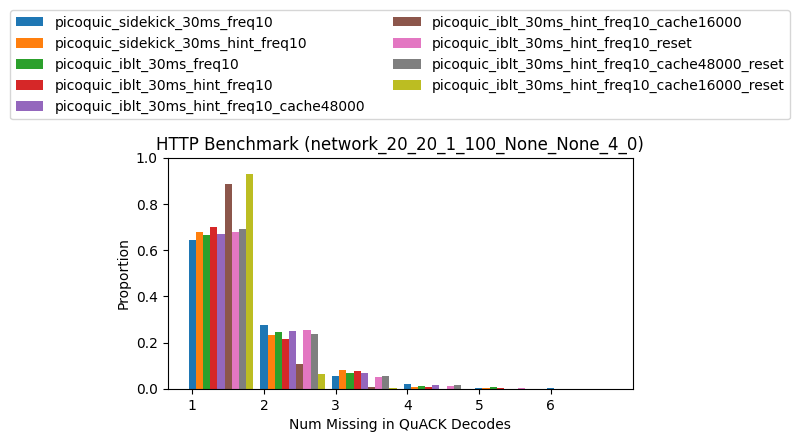

picoquic_sidekick_30ms_freq10 929 {'ExceededThreshold': 5}
picoquic_iblt_30ms_freq10 1230 {'InvalidIBLT': 18, 'NotASubset': 3}
picoquic_sidekick_30ms_hint_freq10 964 {'InvalidThreshold': 8}
picoquic_iblt_30ms_hint_freq10 1863 {'InvalidIBLT': 16, 'NotASubset': 1}


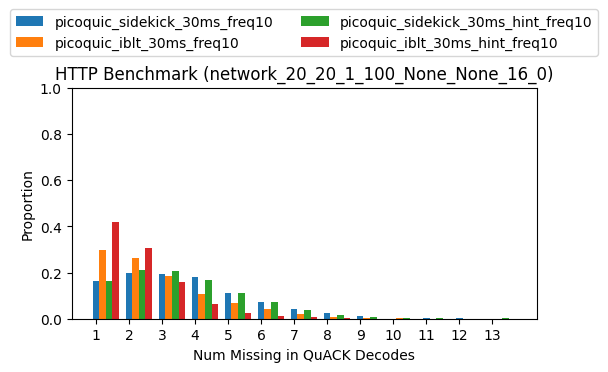

In [46]:
# plot_decode_statistics(http_labels=http_labels, media_labels=media_labels, pdf='../figures/decode_statistics.pdf')
plot_decode_statistics(network_setting=loss4, http_labels=http_labels, title=f'HTTP Benchmark ({loss4.label()})', overlay=False, ncol=2)
plot_decode_statistics(network_setting=loss16, http_labels=[
    'picoquic_sidekick_30ms_freq10',
    'picoquic_iblt_30ms_freq10',
    'picoquic_sidekick_30ms_hint_freq10',
    'picoquic_iblt_30ms_hint_freq10',
], title=f'HTTP Benchmark ({loss16.label()})', overlay=False, ncol=2)

psum_delay0 19 {}
psum_delay45 21 {}
psum_delay90 22 {}
psum_delay45_hint 29 {}
psum_delay45_nack 20 {}
psum_delay45_hint_nack 19 {}
iblt_delay0 18 {}
iblt_delay45 20 {}
iblt_delay90 20 {}
iblt_delay45_hint 15 {}
iblt_delay45_nack 20 {}
iblt_delay45_hint_nack 19 {}
iblt_delay45_hint_nack_cache2000 23 {'MissingLastValue': 1}
iblt_delay45_hint_nack_cache10000 23 {}
psum_delay45_hint_nack_cache10000 28 {}


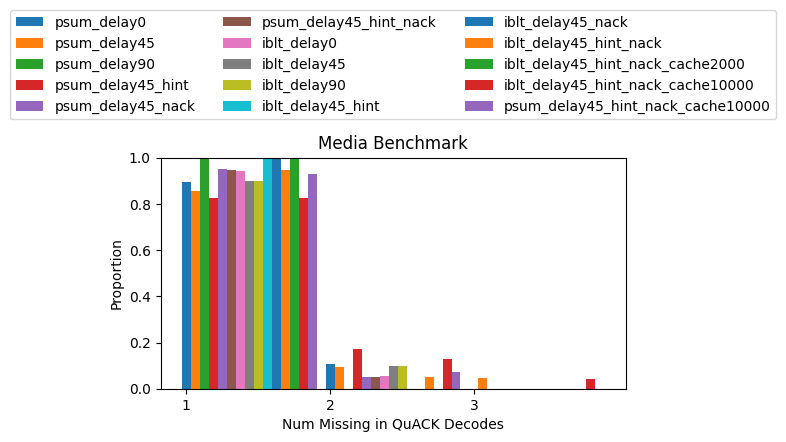

In [10]:
plot_decode_statistics(media_labels=media_labels, overlay=False, title='Media Benchmark')

## Cache statistics

In [11]:
def parse_cache_statistics(data_home, label, pkts=False):
    # Read the raw data file
    filename = f'{data_home}/{label}/router.log'
    if not Path(filename).is_file():
        print('MISSING:', filename)
        return
    with open(filename, 'r') as f:
        lines = f.readlines()

    # Parse the raw data
    xs = [] # time, in secs
    ys = [] # cache size, in bytes
    for line in lines:
        match = re.search(r'cache_statistics Instant { tv_sec: (\d+), tv_nsec: (\d+) } (\w+) nbytes=(\d+) len=(\d+)', line)
        if not match:
            continue
        tv_sec = int(match.group(1))
        tv_nsec = int(match.group(2))
        event = match.group(3)
        nbytes = int(match.group(4))
        npkts = int(match.group(5))
        xs.append(tv_sec + tv_nsec / 1000000000.0)
        if pkts:
            ys.append(npkts)
        else:
            ys.append(nbytes / 1000.0) # bytes to kB

    # Normalize data
    print(label, len(xs))
    xmin = xs[0]
    xs = [x - xmin for x in xs]
    return { 'xs': xs, 'ys': ys }

In [12]:
def format_cache_statistics_data(http_labels, media_labels, pkts=False):
    data = {}
    for http_label in http_labels:
        data[http_label] = parse_cache_statistics(http_data_home, http_label, pkts=pkts)
    for media_label in media_labels:
        data[media_label] = parse_cache_statistics(media_data_home, media_label, pkts=pkts)
    return dict(filter(lambda item: item[1] is not None, data.items()))

In [13]:
def plot_cache_statistics(http_labels=[], media_labels=[], pkts=False, title=None, xlim=0, ylim=0, pdf=None):
    # Parse data and keys as full x range across all dictionaries
    all_data = format_cache_statistics_data(http_labels, media_labels, pkts=pkts)
    labels = list(filter(lambda label: label in all_data, http_labels + media_labels))       
    
    # Plot each treatment
    plt.figure(figsize=(6, 3))
    for i, label in enumerate(labels):
        data = all_data[label]
        plt.step(data['xs'], data['ys'], where='post', label=label)

    # Format axes
    plt.xlabel('Time (s)')
    if pkts:
        plt.ylabel('Cache Size (Packets)')
    else:
        plt.ylabel('Cache Size (kB)')
    plt.xlim(xlim)
    plt.ylim(ylim)
    
    # Plot legend and title above
    plot_title_and_legend(title, labels, ncol=2, base_height=1.15, row_height=0.1, title_height=0.12)

    # Save the PDF
    if pdf:
        save_pdf(pdf)
    plt.show()

picoquic_sidekick_30ms_freq10 19697
picoquic_sidekick_30ms_hint_freq10 19650
picoquic_iblt_30ms_freq10 19674
picoquic_iblt_30ms_hint_freq10 19637


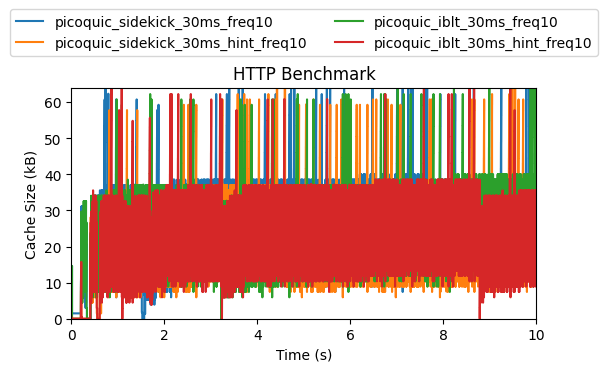

picoquic_iblt_30ms_hint_freq10 19637
picoquic_iblt_30ms_hint_freq10_cache48000 19593
picoquic_iblt_30ms_hint_freq10_cache16000 20597


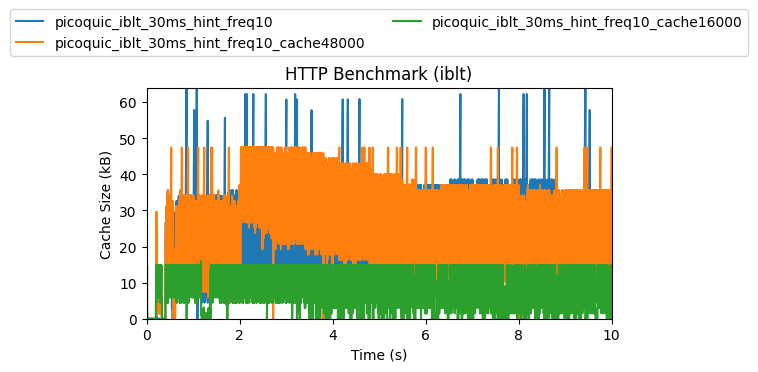

picoquic_iblt_30ms_hint_freq10_cache48000 19593
picoquic_iblt_30ms_hint_freq10_cache48000_reset 19666


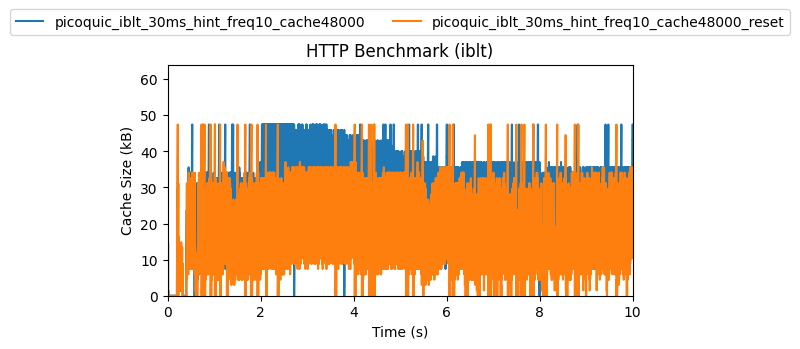

picoquic_iblt_30ms_hint_freq10_cache16000 20597
picoquic_iblt_30ms_hint_freq10_cache16000_reset 22064


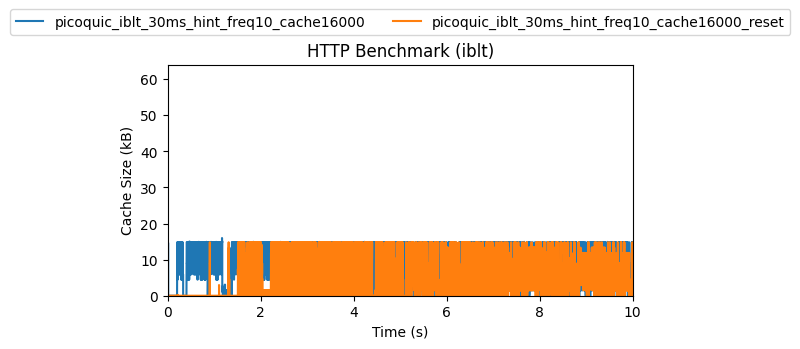

In [26]:
xlim = (0,10)
plot_cache_statistics(http_labels=[
    'picoquic_sidekick_30ms_freq10',
    'picoquic_sidekick_30ms_hint_freq10',
    'picoquic_iblt_30ms_freq10',
    'picoquic_iblt_30ms_hint_freq10',
], xlim=xlim, ylim=(0,64), title='HTTP Benchmark')
plot_cache_statistics(http_labels=[
    'picoquic_iblt_30ms_hint_freq10',
    'picoquic_iblt_30ms_hint_freq10_cache48000',
    'picoquic_iblt_30ms_hint_freq10_cache16000',
], xlim=xlim, ylim=(0,64), title='HTTP Benchmark (iblt)')
plot_cache_statistics(http_labels=[
    'picoquic_iblt_30ms_hint_freq10_cache48000',
    'picoquic_iblt_30ms_hint_freq10_cache48000_reset',
], xlim=xlim, ylim=(0,64), title='HTTP Benchmark (iblt)')
plot_cache_statistics(http_labels=[
    'picoquic_iblt_30ms_hint_freq10_cache16000',
    'picoquic_iblt_30ms_hint_freq10_cache16000_reset',
], xlim=xlim, ylim=(0,64), title='HTTP Benchmark (iblt)')

iblt_delay45_hint 869
iblt_delay45_hint_nack 652
iblt_delay45_hint_nack_cache2000 691
iblt_delay45_hint_nack_cache10000 687


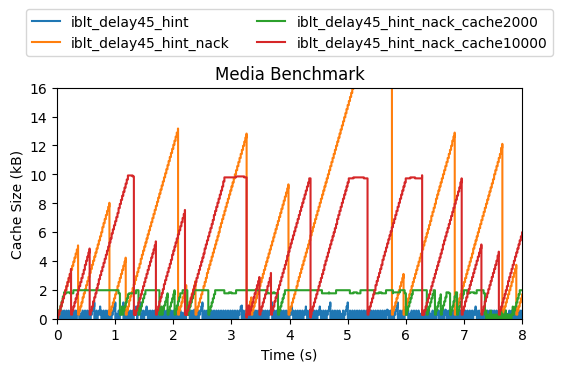

In [15]:
plot_cache_statistics(media_labels=[
    'iblt_delay45_hint',
    'iblt_delay45_hint_nack',
    'iblt_delay45_hint_nack_cache2000',
    'iblt_delay45_hint_nack_cache10000',
], xlim=(0, 8), ylim=(0,16), title='Media Benchmark')